# Cosimita: inertial simulation and occultation

Notebook 00 built sources normalized by flux; notebook 01 built an orbit and
an attitude history around a toy Earth, with the detector nowhere in sight.
This notebook puts the two together and adds the piece neither one had yet:
photons.

Until now every source in the tutorials sat at a fixed **detector-frame**
off-axis angle -- the detector was the centre of the universe, and nothing
moved. `InertialSimulator` flips that around: the sky stands still, sources
live at fixed **inertial** directions, and the spacecraft -- with its orbit
and attitude history from notebook 01 -- moves underneath them. What a
far-field source's off-axis angle *is*, at any moment, now depends on where
the spacecraft is pointing.

**Frame conventions**, stated plainly because everything below depends on
getting them right (plan Section 3.2-3.4):

- `attitude` (`A`): the inertial angle of the detector's own **+y** axis,
  CCW from inertial +X. This is where the spacecraft is pointing.
- `sky_angle` (`lambda`): the inertial direction of a source, CCW from
  inertial +X, pointing *toward* the source. This is where the source is.
- The off-axis angle the detector actually sees is `Nu = A - lambda`: the
  gap between where the instrument points and where the source sits.

Still flatland: the Earth is a circle, the sky is a 1D circle of directions,
angles are the only "solid angle" there is.

A note on which detector this notebook uses: it's **COMPTELito**
(`docs/tutorials/compton_telescopes/01-the_toy_compton_detector.ipynb`), the
same choice notebook 00 made and for the same reason.
`SimpleTraditionalReconstructor` requires the first hit to land in layer
index 0 and treats everything below it as a calorimeter -- true of
COMPTELito's tracker-on-top layout, not of COSIta's uniform stack, whose
layer 0 sits at the *bottom*. There is no reconstructor suited to a
COSIta-like configuration yet, so COMPTELito is what lets the rest of this
notebook show real reconstructed data.

In [1]:
from gammaraytoys import ToyTracker2D
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# COMPTELito, the traditional (tracker-on-top, calorimeter-below) detector
# from tutorial 01, reused here verbatim -- see the note above for why.
comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

print(f"throwing_plane_size = {comptelito.throwing_plane_size:.4f}")

throwing_plane_size = 10.4403 m


## 2. The transform, concretely

`gammaraytoys.coordinates.transform` holds the three formulas of plan Section 3.4,
derived once and shared by every source and by `InertialSimulator` itself.
The one this notebook leans on constantly is `sky_angle_to_offaxis`:
`Nu = A - lambda`, wrapped to `[-180, 180)` degrees.

Two cases are hand-checkable on sight, and are exactly the sanity check the
plan itself gives:

- `A = 90 deg`, `lambda = 90 deg`: the detector's +y axis points along
  inertial +Y, and the source sits in exactly that direction, so it's
  **on-axis**, `Nu = 0`.
- `A = 90 deg`, `lambda = 0 deg`: the source sits along inertial +X, which
  is now `90 deg` around from the detector's +y (CCW), i.e. on the
  detector's **+x side** -- `Nu = 90 deg`.

In [2]:
from gammaraytoys.coordinates import (sky_angle_to_offaxis, offaxis_to_sky_angle,
                                      inertial_to_detector_direction)

cases = [
    (90*u.deg, 90*u.deg, 0*u.deg,  "on-axis"),
    (90*u.deg,  0*u.deg, 90*u.deg, "detector's +x side"),
]

for attitude, sky_angle, expected_nu, note in cases:
    nu = sky_angle_to_offaxis(sky_angle, attitude)
    print(f"A = {attitude:>6}, lambda = {sky_angle:>6}  ->  Nu = {nu:>7.2f}   "
          f"({note}, expected {expected_nu})")
    assert np.isclose(nu.to_value(u.deg), expected_nu.to_value(u.deg))

A =   90.0 deg, lambda =   90.0 deg  ->  Nu =    0.00 deg   (on-axis, expected 0.0 deg)
A =   90.0 deg, lambda =    0.0 deg  ->  Nu =   90.00 deg   (detector's +x side, expected 90.0 deg)


That's the whole formula for far-field sources. The one thing worth
proving rather than just asserting is that this new inertial convention
**agrees** with the detector-frame convention every tutorial already uses --
"a source at off-axis angle `Nu` lies along `(sin Nu, cos Nu)`, and the
photon it emits flies along `270 deg - Nu`" (plan Section 3.3).

A far-field photon coming from inertial sky angle `lambda` flies in the
*opposite* inertial direction, `lambda + 180 deg`. Running that through
`inertial_to_detector_direction` (`direction_det = direction_inertial - A +
90 deg`):

```
(lambda + 180) - A + 90 = 270 - (A - lambda) = 270 deg - Nu
```

exactly the existing detector-frame formula. This identity is what
guarantees the two frames can never quietly disagree: any far-field photon
built through the inertial machinery flies in precisely the direction the
detector-frame code has always expected. Let's check it numerically, across
a spread of angles that includes an unwrapped attitude (`450 deg`, past a
full turn) and a negative sky angle, since the identity has to survive both:

In [3]:
rng = np.random.default_rng(1)

n = 5000
sky_angle = (rng.uniform(-720, 720, n)) * u.deg
attitude = (rng.uniform(-720, 720, n)) * u.deg

nu = sky_angle_to_offaxis(sky_angle, attitude)  # wrapped to [-180, 180)

direction_inertial = sky_angle + 180*u.deg
direction_det = inertial_to_detector_direction(direction_inertial, attitude)

# Both sides wrapped to [0, 360) before comparing -- direction_det is
# deliberately left unwrapped by the transform (it has to match the
# existing, also-unwrapped, 270 - offaxis_angle convention), and Nu is
# wrapped to [-180, 180) by sky_angle_to_offaxis, so the raw numbers differ
# by a multiple of 360 deg even though the physical direction is identical.
lhs = direction_det.to_value(u.deg) % 360.0
rhs = (270*u.deg - nu).to_value(u.deg) % 360.0

max_diff = np.max(np.abs(lhs - rhs))
print(f"max |direction_det - (270 deg - Nu)|, mod 360 deg: {max_diff:.2e} deg")

assert max_diff < 1e-9

max |direction_det - (270 deg - Nu)|, mod 360 deg: 1.14e-13 deg


Exact agreement, to floating-point precision, over 5000 random cases
including angles well outside `[0, 360)` on both sides. This is the
guarantee the rest of the notebook leans on: an inertial source's photon,
once thrown, is indistinguishable from a detector-frame photon aimed at the
`Nu` the transform predicts.

## 3. A source that stays put while the spacecraft turns

This is the central point of the whole notebook: **the sky doesn't move,
the instrument does.** A `PointSource` built with `sky_angle` sits at one
fixed inertial direction for its entire life. As the spacecraft's attitude
changes, the off-axis angle that source appears at changes right along with
it -- not because the source moved, but because the detector's own +y axis
is pointing somewhere new.

Let's pick up the 550 km circular orbit from notebook 01 and fly a
zenith-pointing spacecraft around it -- `ZenithPointing` sets `A = theta`,
so over one full orbit the attitude sweeps smoothly through all 360 degrees,
which is exactly what will make the sweep below easy to see.

In [4]:
from gammaraytoys.sims import Earth, SpacecraftHistory, ZenithPointing

earth = Earth()
altitude = 550*u.km
semi_major_axis = earth.radius + altitude

history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis = semi_major_axis, time_step = 30*u.s,
    observation_strategy = ZenithPointing(), earth = earth)

rho = earth.angular_radius(semi_major_axis)

print(f"nintervals      = {history.nintervals}")
print(f"total_livetime  = {history.total_livetime:.1f}")
print(f"rho             = {rho:.3f}  (Earth's angular radius at this altitude)")

nintervals      = 191
total_livetime  = 5738.9 s
rho             = 67.016 deg  (Earth's angular radius at this altitude)


Now a source: the same `sky_angle = 40 deg` notebook 01 used for its
`TargetedPointing` demo, so this is literally the source that spacecraft was
tracking. Here it's built with a plain `sky_angle` -- no attitude tracking,
just a fixed point on the sky -- so `InertialSimulator` will see it drift
in and out of view as the zenith-pointing spacecraft's attitude sweeps past
it.

One gotcha worth hitting deliberately before running anything: `PointSource
.random_photon(detector, pose=None, earth=None)` takes the pose as its
second parameter (keeping `detector` first-positional-or-keyword, as the
tutorials require) and the Earth as its third. A `sky_angle` source is
**occultable** by default, so calling it with a `pose` but no `earth` is a
configuration error, not a silent default -- it raises rather than quietly
assuming some `Earth()` that might not match the rest of the run:

In [5]:
from gammaraytoys.sims import PointSource, MonoenergeticSpectrum

target = PointSource(sky_angle = 40*u.deg,
                     spectrum = MonoenergeticSpectrum(1*u.MeV),
                     flux = 1/u.cm/u.s)

pose = next(iter(history))

try:
    target.random_photon(comptelito, pose)  # pose given, earth omitted
except ValueError as err:
    print(f"ValueError: {err}")

ValueError: PointSource is occultable and was given a pose (inertial mode), so it needs an `earth` to test occultation against. Pass `earth`, e.g. the same `Earth` the spacecraft history was built with.


Exactly as documented. `InertialSimulator` always supplies both, so
this only bites when calling `random_photon` by hand -- which is worth
knowing before it does.

Now the real run. `flux` is tuned so the *unocculted* expected count over
this orbit is a round number, using `simulated_rate = flux *
throwing_plane_size` (section 5.2 of the plan) times the total livetime:

In [6]:
from gammaraytoys.sims import InertialSimulator, SimpleTraditionalReconstructor

sky_angle = 40*u.deg
mu_target = 8000.0
flux = (mu_target / (comptelito.throwing_plane_size * history.total_livetime)).to(1/u.cm/u.s)

source = PointSource(sky_angle = sky_angle,
                     spectrum = MonoenergeticSpectrum(1*u.MeV),
                     flux = flux)

reco = SimpleTraditionalReconstructor()
sim = InertialSimulator(detector = comptelito, sources = source, reconstructor = reco,
                        spacecraft_history = history, earth = earth)

events = list(sim.run_events())

print(f"unocculted mean mu = {mu_target:.0f}  ->  drawn {sim.nsim + sim.noccult}, "
      f"launched {sim.nsim} (occulted {sim.noccult})")

  0%|          | 0/8000.000000000011 [00:00<?, ?it/s]

  0%|          | 12/8000.000000000011 [00:00<01:06, 119.83it/s]

  0%|          | 25/8000.000000000011 [00:00<01:07, 117.51it/s]

  1%|          | 43/8000.000000000011 [00:00<00:57, 137.58it/s]

  1%|          | 57/8000.000000000011 [00:00<01:04, 124.06it/s]

...

 79%|███████▉  | 6313/8000.000000000011 [00:20<00:00, 6863.44it/s]

 89%|████████▉ | 7121/8000.000000000011 [00:22<00:00, 1344.77it/s]

 96%|█████████▌| 7700/8000.000000000011 [00:25<00:00, 569.95it/s] 

 99%|█████████▊| 7888/8000.000000000011 [00:26<00:00, 298.14it/s]

unocculted mean mu = 8000  ->  drawn 7888, launched 5041 (occulted 2847)


Now the payoff. For every photon actually launched, recover its
off-axis angle from the thrown direction the same way `run_binned` already
does it internally (`Nu = 270 deg - direction`), and pair it with the
attitude of the interval it was thrown from. `run_events` doesn't hand back
the pose directly, so intervals are looked up by timestamp -- each event's
time falls in exactly one `[start_time, stop_time)` span.

In [7]:
intervals = list(history)
interval_starts = np.array([iv.start_time.to_value(u.s) for iv in intervals])
interval_attitudes = np.array([iv.attitude.to_value(u.deg) for iv in intervals])

def wrap180(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

times = np.array([t.to_value(u.s) for t, _, _, _ in events])
nu_thrown = np.array([(270*u.deg - sim_event.direction).to_value(u.deg)
                      for _, _, sim_event, _ in events])

# Interval i spans [start_i, start_{i+1}); searchsorted(..., side='right') - 1
# finds that i directly from the sorted start times.
idx = np.searchsorted(interval_starts, times, side = 'right') - 1
attitude_at_event = interval_attitudes[idx]

residual = wrap180(attitude_at_event - nu_thrown - sky_angle.to_value(u.deg))

print(f"attitude swept from {attitude_at_event.min():.1f} to {attitude_at_event.max():.1f} deg")
print(f"max |A - Nu - lambda| = {np.max(np.abs(residual)):.2e} deg")

attitude swept from 0.0 to 358.1 deg
max |A - Nu - lambda| = 5.68e-14 deg


Zero, to floating-point precision, over every single photon this run
launched -- not a statistical near-match, an identity. Let's see what that
identity looks like: `Nu` sweeping with the attitude on the left, and
`A - Nu` sitting dead flat at `lambda = 40 deg` on the right.

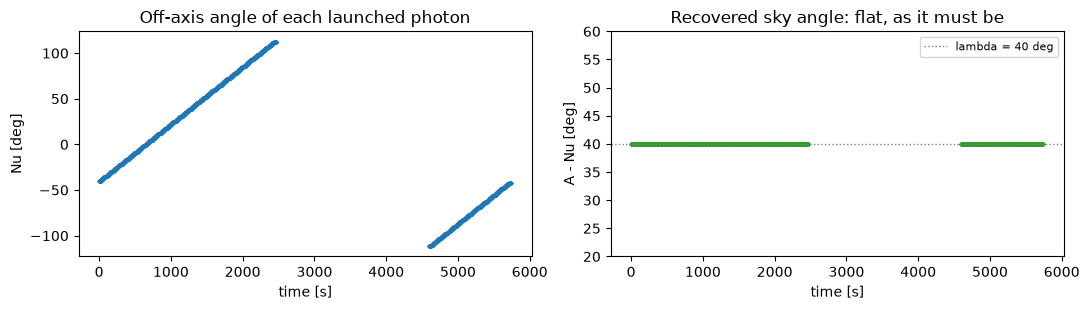

In [8]:
fig, ax = plt.subplots(figsize = (11, 3.2), ncols = 2)

ax[0].plot(times, wrap180(nu_thrown), '.', ms = 3, color = 'tab:blue')
ax[0].set_xlabel('time [s]')
ax[0].set_ylabel('Nu [deg]')
ax[0].set_title('Off-axis angle of each launched photon')

ax[1].plot(times, wrap180(attitude_at_event - nu_thrown), '.', ms = 3, color = 'tab:green')
ax[1].axhline(sky_angle.to_value(u.deg), color = 'gray', ls = ':', lw = 1,
              label = f'lambda = {sky_angle:.0f}')
ax[1].set_xlabel('time [s]')
ax[1].set_ylabel('A - Nu [deg]')
ax[1].set_ylim(sky_angle.to_value(u.deg) - 20, sky_angle.to_value(u.deg) + 20)
ax[1].set_title('Recovered sky angle: flat, as it must be')
ax[1].legend(loc = 'upper right', fontsize = 8)

fig.tight_layout()

`Nu` sweeps across the full range as the attitude turns underneath
the source -- gaps in the sweep are the stretches where the source was
behind the Earth and no photon was launched at all, taken up in section 4.
`A - Nu` is the same data, just rearranged to undo the sweep: a flat line at
`40 deg`, because that's what it algebraically has to be. The source never
moved; only the instrument did.

### The measured Compton Data Space, in both frames

Section 2's `Nu`-sweep above is the geometry underneath everything; the
Compton Data Space (`Em`, `Phi`, `Psi`, from
`docs/tutorials/compton_telescopes/02-measured_energy_n_CDS.ipynb`) is what
an analyst actually has. `Psi` lives in exactly the same detector-frame
convention as `Nu` -- CCW from the detector's own +y, and that tutorial's
ARM check (`arm = |psi - source.offaxis_angle| - phi`) is precisely what
says so: at `phi = 0` the two coincide. So the same `offaxis_to_sky_angle`
transform that turned the sweeping `Nu` into a flat `lambda = 40 deg` above
turns the measured `Psi` into an inertial-frame `Psi` just as directly --
no new physics, just the same rotation applied to a different
detector-frame angle.

Only the triggered events from the run above are needed; each one already
carries `(Em, Phi, Psi)`, and the same interval lookup used for the sweep
gives its attitude.

300 triggered events out of 5041 launched this run


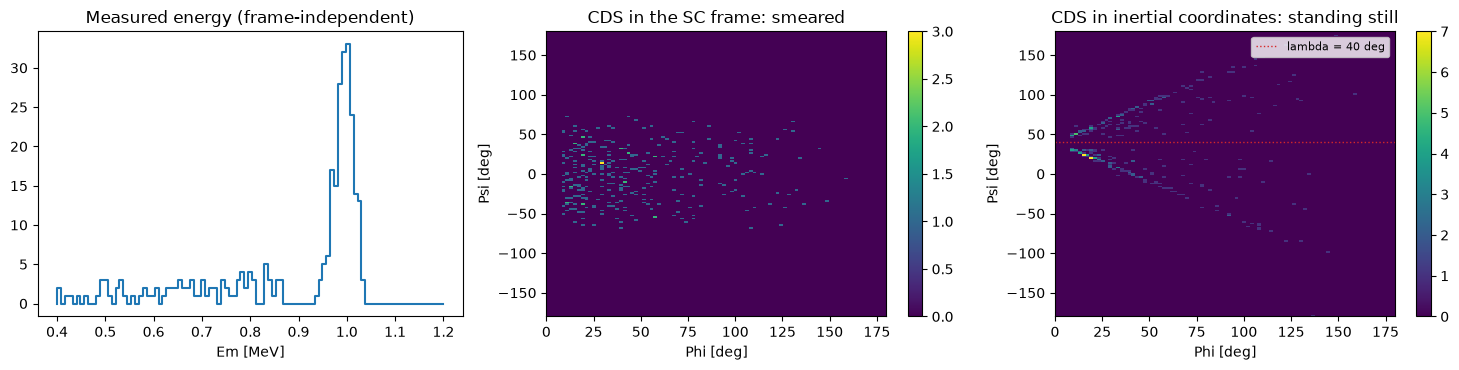

In [9]:
from histpy import Histogram, Axis

triggered = [(t, se, re) for t, _, se, re in events if re.triggered]
triggered_mask = np.array([re.triggered for _, _, _, re in events])
print(f"{len(triggered)} triggered events out of {sim.nsim} launched this run")

times_trig = np.array([t.to_value(u.s) for t, _, _ in triggered])
idx_trig = np.searchsorted(interval_starts, times_trig, side = 'right') - 1
attitude_trig = interval_attitudes[idx_trig] * u.deg

em = u.Quantity([re.energy for _, _, re in triggered])
phi = u.Quantity([re.phi for _, _, re in triggered]).to(u.deg)
psi_sc = u.Quantity([re.psi for _, _, re in triggered]).to(u.deg)

# Same transform as the Nu-sweep above, applied to the measured Psi instead
# of the thrown Nu.
psi_inertial = offaxis_to_sky_angle(psi_sc, attitude_trig)

h_Em = Histogram(Axis(np.linspace(.4, 1.2, 100)*u.MeV, label = 'Em'))
h_Em.fill(em, warn_overflow = False)

phi_axis = Axis(np.linspace(0, 180, 90)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 180)*u.deg, label = 'Psi')

h_CDS_sc = Histogram([phi_axis, psi_axis])
h_CDS_sc.fill(phi, psi_sc, warn_overflow = False)

h_CDS_inertial = Histogram([phi_axis, psi_axis])
h_CDS_inertial.fill(phi, psi_inertial, warn_overflow = False)

fig, ax = plt.subplots(figsize = (15, 3.8), ncols = 3)

h_Em.plot(ax[0])
ax[0].set_title('Measured energy (frame-independent)')

h_CDS_sc.plot(ax[1])
ax[1].set_title('CDS in the SC frame: smeared')

h_CDS_inertial.plot(ax[2])
ax[2].axhline(sky_angle.to_value(u.deg), color = 'tab:red', ls = ':', lw = 1,
             label = f'lambda = {sky_angle:.0f}')
ax[2].set_title('CDS in inertial coordinates: standing still')
ax[2].legend(loc = 'upper right', fontsize = 8)

fig.tight_layout()

The measured energy (left) doesn't know or care which frame we're in -- the
photopeak sits at 1 MeV regardless, so it's shown once. The Compton Data
Space does care, and the two right-hand panels are the *same* triggered
events, projected two different ways:

- **SC frame** (middle): each event's `Psi` sits near that photon's own
  `Nu`, and `Nu` swept across the source's entire visible range as the
  spacecraft turned underneath it -- so the events smear across nearly the
  whole `Psi` axis, and no single cone is visible at all.
- **Inertial frame** (right): the same events, each corrected for the
  attitude it was measured at. The smearing collapses into a single
  Compton cone, its apex sitting right at the dotted line, `lambda = 40
  deg` -- the source's one, fixed sky position. This is the same "sky
  stands still" argument as the `Nu`-sweep above, now made in the actual
  data space an analyst works with, rather than in an idealized off-axis
  angle.

## 4. Occultation

### 4.1 The duty cycle over a full orbit

For a circular orbit, occultation of a fixed-sky-angle source has a clean
closed form (plan Section 7, PR 3): nadir sweeps the full `360 deg` once per
orbit, and the source is blocked whenever nadir passes within `rho` of it --
an arc of `2 rho` out of `2 pi`, so the occulted **duty cycle** is `rho /
pi`, independent of where on the sky the source actually sits. This is pure
geometry, the same `Earth.is_occulted` check notebook 01 used, with no
detector or simulator involved at all. Let's fly a *full* orbit (rather than
the earlier run's partial one) and check it:

rho                          = 67.0159 deg
occulted duty cycle, numeric = 0.3717
occulted duty cycle, rho/pi  = 0.3723
relative difference          = 0.16%


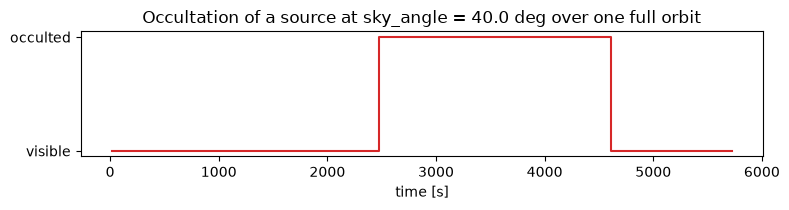

In [10]:
full_history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis = semi_major_axis, time_step = 30*u.s,
    observation_strategy = ZenithPointing(), earth = earth)

full_intervals = list(full_history)
t_mid = u.Quantity([iv.mid_time for iv in full_intervals])
orbit_angle = u.Quantity([iv.orbit_angle for iv in full_intervals])
orbit_radius = u.Quantity([iv.orbit_radius for iv in full_intervals])

occulted = earth.is_occulted(sky_angle, orbit_angle, orbit_radius)

fig, ax = plt.subplots(figsize = (8, 2.2))
ax.step(t_mid.to_value(u.s), occulted.astype(int), where = 'post', color = 'tab:red')
ax.set_xlabel('time [s]')
ax.set_yticks([0, 1])
ax.set_yticklabels(['visible', 'occulted'])
ax.set_title(f'Occultation of a source at sky_angle = {sky_angle} over one full orbit')
fig.tight_layout()

duty_numeric = np.mean(occulted)
duty_analytic = (rho / (180*u.deg)).to_value(u.dimensionless_unscaled)  # rho/pi, rho in radians

print(f"rho                          = {rho:.4f}")
print(f"occulted duty cycle, numeric = {duty_numeric:.4f}")
print(f"occulted duty cycle, rho/pi  = {duty_analytic:.4f}")
print(f"relative difference          = {abs(duty_numeric - duty_analytic) / duty_analytic:.2%}")

They agree to well under a percent -- the residual is just the
`30 s` time step discretizing exactly when the limb crossings fall.

### 4.2 The visible wedge: where an `IsotropicSource` loses photons

A single fixed-sky-angle source gives an on/off signal, but the clearest
picture of occultation comes from a source that covers the *whole* sky at
once: an `IsotropicSource`, frozen at one pose. From the spacecraft, the
Earth carves a wedge of width `2 rho` out of the sky, centred on nadir. In
the detector frame that wedge sits at

```
Nu = A - nadir = A - (theta + 180 deg)
```

-- the same reflection `lambda -> Nu = A - lambda` that makes any inertial
geometry legible in the detector frame (section 2 above), just applied to
the nadir direction instead of a source direction.

Let's freeze a pose with a *non-trivial* attitude -- `orbit_angle = 0 deg`,
`attitude = 50 deg` -- specifically so the wedge isn't centred on `Nu = 0`
by coincidence (with `ZenithPointing`, `A = theta` always, so the wedge
would sit at the same `Nu = -180 deg` at every pose -- true, but it would
hide whether the formula above is really using `A` and not just `theta`).

In [11]:
from gammaraytoys.sims import SpacecraftInterval

frozen_orbit_angle = 0*u.deg
frozen_attitude = 50*u.deg

pose = SpacecraftInterval(start_time = 0*u.s, stop_time = 1*u.s, livetime = 1*u.s,
                          orbit_radius = semi_major_axis,
                          orbit_angle = frozen_orbit_angle, attitude = frozen_attitude)

nadir = frozen_orbit_angle + 180*u.deg
expected_center = wrap180((frozen_attitude - nadir).to_value(u.deg))
expected_halfwidth = rho.to_value(u.deg)

print(f"nadir            = {nadir}")
print(f"expected centre  = Nu = {expected_center:.2f} deg")
print(f"expected width   = 2 rho = {2*expected_halfwidth:.2f} deg")

nadir            = 180.0 deg
expected centre  = Nu = -130.00 deg
expected width   = 2 rho = 134.03 deg


In [12]:
from gammaraytoys.sims import IsotropicSource

isotropic = IsotropicSource(spectrum = MonoenergeticSpectrum(1*u.MeV), flux = 1/u.cm/u.s)

n_draws = 8000
nu_survivors = []
n_occulted = 0

for _ in range(n_draws):
    photon = isotropic.random_photon(comptelito, pose, earth)
    if photon is None:
        n_occulted += 1
        continue
    nu_survivors.append((270*u.deg - photon.direction).to_value(u.deg) % 360.0)

nu_survivors = np.sort(np.array(nu_survivors))
print(f"{n_draws} draws: {n_occulted} occulted, {len(nu_survivors)} survived "
      f"({n_occulted/n_draws:.1%} occulted, vs rho/pi = {duty_analytic:.1%})")

# The occulted arc is the one gap in an otherwise uniform coverage of the
# sky -- find it as the single largest gap between consecutive survivors
# (wrapping around 360 -> 0), purely from the data, with no reference to the
# analytic formula above.
gaps = np.diff(nu_survivors)
wrap_gap = 360.0 - nu_survivors[-1] + nu_survivors[0]
widest = np.argmax(np.append(gaps, wrap_gap))
if widest < len(gaps):
    gap_lo, gap_hi = nu_survivors[widest], nu_survivors[widest + 1]
else:
    gap_lo, gap_hi = nu_survivors[-1], nu_survivors[0] + 360.0

empirical_width = gap_hi - gap_lo
empirical_center = wrap180(gap_lo + empirical_width / 2)

print(f"empirical centre = {empirical_center:.2f} deg   (predicted {expected_center:.2f})")
print(f"empirical width  = {empirical_width:.2f} deg   (predicted {2*expected_halfwidth:.2f})")

8000 draws: 3000 occulted, 5000 survived (37.5% occulted, vs rho/pi = 37.2%)
empirical centre = -130.00 deg   (predicted -130.00)
empirical width  = 134.04 deg   (predicted 134.03)


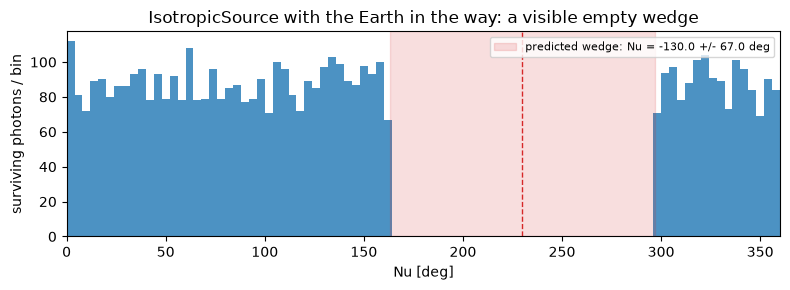

In [13]:
# Plotted on [0, 360) rather than wrap180's [-180, 180): this particular
# wedge (centred at Nu = -130 deg) straddles the +/-180 deg cut, which would
# otherwise split the shaded region into two pieces at the plot's edges.
# [0, 360) keeps the *wedge* (163 to 297 deg) in one contiguous span instead
# -- nu_survivors is already in [0, 360) from the `% 360.0` above.
center_0_360 = expected_center % 360.0

fig, ax = plt.subplots(figsize = (8, 3))

ax.hist(nu_survivors, bins = 90, range = (0, 360), color = 'tab:blue', alpha = .8)

lo = center_0_360 - expected_halfwidth
hi = center_0_360 + expected_halfwidth
ax.axvspan(lo, hi, color = 'tab:red', alpha = .15,
          label = f'predicted wedge: Nu = {expected_center:.1f} +/- {expected_halfwidth:.1f} deg')
ax.axvline(center_0_360, color = 'tab:red', ls = '--', lw = 1)

ax.set_xlim(0, 360)
ax.set_xlabel('Nu [deg]')
ax.set_ylabel('surviving photons / bin')
ax.set_title('IsotropicSource with the Earth in the way: a visible empty wedge')
ax.legend(loc = 'upper right', fontsize = 8)
fig.tight_layout()

The empty band lines up with the shaded prediction exactly, and the
gap-finding cross-check above agrees with the analytic centre and width to
a fraction of a degree -- pure sampling noise at 8000 draws. This is the
single clearest picture of occultation in the whole project: nothing was
truncated or masked by hand, `IsotropicSource.random_photon` drew a
direction, tested it against the Earth via `sky_angle`, and rejected it if
blocked -- exactly the per-photon mechanism `InertialSimulator` uses for
every far-field source, point or extended alike.

## 5. Counts

Section 6 of the plan draws a Poisson count per `(source, interval)` from
the *unocculted* mean, then rejects the occulted photons afterward. That
means occultation should show up as photons **removed from** the unocculted
Poisson mean, not as a change to what that mean is. The run from section 3
already has everything needed to check both halves of that claim, with no
new simulation required.

In [14]:
total_drawn = sim.nsim + sim.noccult   # every Poisson draw, occulted or not
expected_unocculted = mu_target
sigma_unocculted = np.sqrt(expected_unocculted)

expected_visible = expected_unocculted * (1 - duty_analytic)
sigma_visible = np.sqrt(expected_visible)

print("Unocculted total (nsim + noccult) vs flux * throwing_plane_size * total_livetime:")
print(f"  observed {total_drawn}, expected {expected_unocculted:.1f}, "
      f"({(total_drawn - expected_unocculted)/sigma_unocculted:+.2f} sigma)")
print()
print("Visible total (nsim alone) vs that same unocculted mean, thinned by (1 - rho/pi):")
print(f"  observed {sim.nsim}, expected {expected_visible:.1f}, "
      f"({(sim.nsim - expected_visible)/sigma_visible:+.2f} sigma)")

Unocculted total (nsim + noccult) vs flux * throwing_plane_size * total_livetime:
  observed 7888, expected 8000.0, (-1.25 sigma)

Visible total (nsim alone) vs that same unocculted mean, thinned by (1 - rho/pi):
  observed 5041, expected 5021.5, (+0.27 sigma)


Both land well within a couple of sigma of their targets: the raw
draw count matches `flux * throwing_plane_size * total_livetime` on its
own, and occultation only ever thins that same mean by `(1 - rho/pi)` -- it
never enters the formula for the mean itself.

One more way to see the same thing, at the level of a single interval
rather than the whole run: every interval here has the same `30 s`
livetime, so every *visible* interval shares one common Poisson mean,
`mu_interval = flux * throwing_plane_size * 30 s`. Occulted intervals
contribute a hard zero, not a smaller Poisson draw -- they were never
sampled from at all. Histogramming the survivor count per visible interval
against that single `mu_interval` is a direct look at the Poisson claim
itself:

mu_interval (analytic)          = 41.885
launched,  visible: mean / var  = 42.008 / 36.925   (Poisson: mean == variance)
triggered, visible: mean / var  = 2.500 / 4.700   (Poisson: mean == variance)


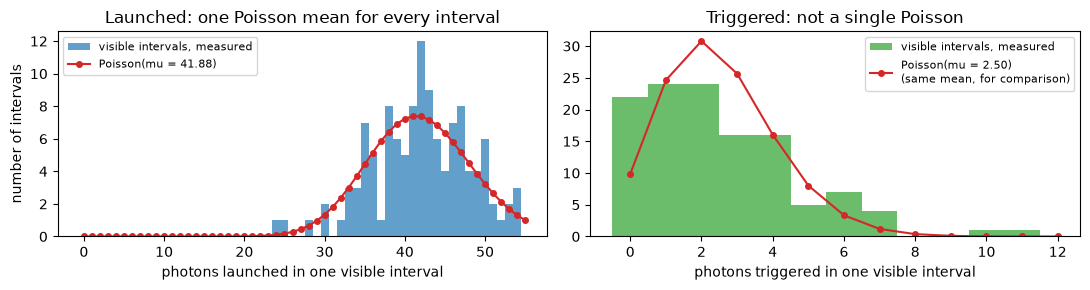

In [15]:
from scipy import stats

interval_livetime = intervals[0].livetime  # identical for every interval here
mu_interval = (flux * comptelito.throwing_plane_size * interval_livetime).to_value(u.dimensionless_unscaled)

occulted_per_interval = np.array([
    earth.is_occulted(sky_angle, iv.orbit_angle, iv.orbit_radius) for iv in intervals])
visible = ~occulted_per_interval

edges = np.append(interval_starts, intervals[-1].stop_time.to_value(u.s))
launched_per_interval, _ = np.histogram(times, bins = edges)
triggered_per_interval, _ = np.histogram(times[triggered_mask], bins = edges)

launched_visible = launched_per_interval[visible]
triggered_visible = triggered_per_interval[visible]

k_launched = np.arange(0, launched_visible.max() + 2)
pmf_launched = stats.poisson.pmf(k_launched, mu_interval) * len(launched_visible)

# Triggered has no single analytic mean the way launched does -- there is no
# "mu_interval" for it. The red curve here is a Poisson with the *measured*
# mean, given to it for free, purely to show how far the actual spread
# strays from a single Poisson of any mean at all.
k_triggered = np.arange(0, triggered_visible.max() + 2)
pmf_triggered = stats.poisson.pmf(k_triggered, triggered_visible.mean()) * len(triggered_visible)

fig, ax = plt.subplots(figsize = (11, 3), ncols = 2)

ax[0].hist(launched_visible, bins = np.arange(-.5, launched_visible.max() + 1.5),
          color = 'tab:blue', alpha = .7, label = 'visible intervals, measured')
ax[0].plot(k_launched, pmf_launched, 'o-', color = 'tab:red', ms = 4,
          label = f'Poisson(mu = {mu_interval:.2f})')
ax[0].set_xlabel('photons launched in one visible interval')
ax[0].set_ylabel('number of intervals')
ax[0].set_title('Launched: one Poisson mean for every interval')
ax[0].legend(fontsize = 8)

ax[1].hist(triggered_visible, bins = np.arange(-.5, triggered_visible.max() + 1.5),
          color = 'tab:green', alpha = .7, label = 'visible intervals, measured')
ax[1].plot(k_triggered, pmf_triggered, 'o-', color = 'tab:red', ms = 4,
          label = f'Poisson(mu = {triggered_visible.mean():.2f})\n(same mean, for comparison)')
ax[1].set_xlabel('photons triggered in one visible interval')
ax[1].set_title('Triggered: not a single Poisson')
ax[1].legend(fontsize = 8)

fig.tight_layout()

print(f"mu_interval (analytic)          = {mu_interval:.3f}")
print(f"launched,  visible: mean / var  = {launched_visible.mean():.3f} / {launched_visible.var():.3f}"
     "   (Poisson: mean == variance)")
print(f"triggered, visible: mean / var  = {triggered_visible.mean():.3f} / {triggered_visible.var():.3f}"
     "   (Poisson: mean == variance)")

**Left**: launched counts still land right on a single Poisson, mean and
variance close together, exactly as before -- occultation only removes
intervals from the sample, it does not touch the shape of what's left over.

**Right**: triggered counts do not. The histogram visibly spills wider than
the red curve, even though that curve was handed the *measured* mean for
free -- the variance printed above sits well past the mean. This is not
occultation's doing: every interval used here is already visible. Something
else is scattering the trigger rate from one visible interval to the next,
and that something is the subject of the rest of this section.

### The light curve

Binning the same triggered events by time gives a light curve. Overlaying
`|Nu(t)|` -- the source's off-axis angle at every moment, from the same
per-interval attitudes used throughout this notebook -- on a second axis
shows why the rate isn't flat. The occulted stretch (shaded) drops it to
zero outright; away from that gap, the trigger rate visibly rises and falls
with `|Nu|`, even though the source's flux never changes at all.

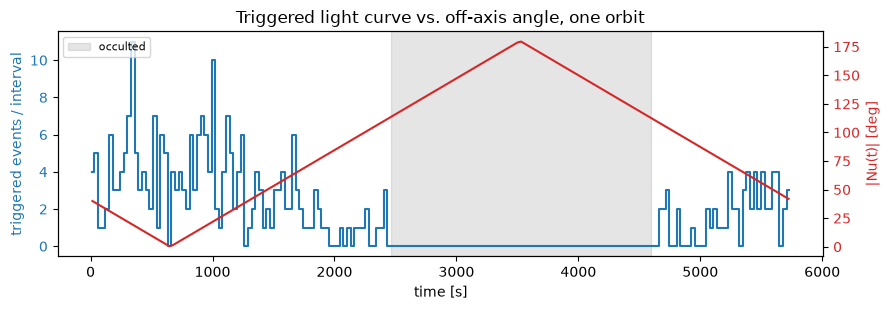

In [16]:
t_mid = 0.5 * (edges[:-1] + edges[1:])
nu_per_interval = wrap180(interval_attitudes - sky_angle.to_value(u.deg))

fig, ax1 = plt.subplots(figsize = (9, 3.2))

ax1.step(t_mid, triggered_per_interval, where = 'mid', color = 'tab:blue')
ax1.set_xlabel('time [s]')
ax1.set_ylabel('triggered events / interval', color = 'tab:blue')
ax1.tick_params(axis = 'y', labelcolor = 'tab:blue')

occulted_idx = np.where(occulted_per_interval)[0]
ax1.axvspan(edges[occulted_idx[0]], edges[occulted_idx[-1] + 1],
           color = 'gray', alpha = .2, label = 'occulted')
ax1.legend(loc = 'upper left', fontsize = 8)

ax2 = ax1.twinx()
ax2.plot(t_mid, np.abs(nu_per_interval), color = 'tab:red', lw = 1.5)
ax2.set_ylabel('|Nu(t)| [deg]', color = 'tab:red')
ax2.tick_params(axis = 'y', labelcolor = 'tab:red')

ax1.set_title('Triggered light curve vs. off-axis angle, one orbit')
fig.tight_layout()

The rate falls as `|Nu|` rises and climbs back as it falls, symmetrically on
both sides of the occulted gap -- exactly the shape effective area has as a
function of off-axis angle for this detector. That's the whole answer to
why the launched counts above are Poisson-consistent while the triggered
counts are not.

### Why launched is Poisson and triggered is not

A photon's *launch* has nothing to do with where the detector is pointed.
Every photon `InertialSimulator` throws is drawn against the surrounding
circle (`draw_surrounding_circle = True` in the CDS tutorial) -- a shape
that looks identical from every direction by construction, which is the
whole reason it's used to normalize the flux. The mean number launched per
interval is `flux * throwing_plane_size * livetime`
(`throwing_plane_size = 2 * surrounding_circle_radius`), and nothing in
that formula depends on the attitude: `Nu` can sweep across the whole sky
and the launched rate does not move.

`Aeff` -- and with it the *trigger* probability -- only enters one step
later, when asking how many of those launched photons actually make it
through the detector and satisfy the trigger condition, and that does
depend on the angle a photon comes in at. Binning this run's visible
intervals by `|Nu|` makes both halves of the claim visible side by side:

In [17]:
abs_nu_per_interval = np.abs(nu_per_interval)
nu_bin_edges = [0, 20, 40, 60, 90, 180]

print(f"{'|Nu| bin':>12}  {'intervals':>9}  {'launched/interval':>18}  "
     f"{'triggered/interval':>19}  {'trigger fraction':>17}")
for lo, hi in zip(nu_bin_edges[:-1], nu_bin_edges[1:]):
    mask = visible & (abs_nu_per_interval >= lo) & (abs_nu_per_interval < hi)
    n = mask.sum()
    if n == 0:
        continue
    launched_mean = launched_per_interval[mask].mean()
    triggered_mean = triggered_per_interval[mask].mean()
    print(f"{lo:>4d}-{hi:<4d} deg  {n:>9d}  {launched_mean:>18.2f}  "
         f"{triggered_mean:>19.3f}  {triggered_mean/launched_mean:>17.4f}")

    |Nu| bin  intervals   launched/interval   triggered/interval   trigger fraction
   0-20   deg         21               42.00                4.333             0.1032
  20-40   deg         21               40.38                3.905             0.0967
  40-60   deg         22               42.68                2.591             0.0607
  60-90   deg         31               41.61                1.581             0.0380
  90-180  deg         25               43.28                0.840             0.0194


Launched stays flat across every `|Nu|` bucket, no trend at all -- pure
sampling scatter around one common mean, matching the dispersion check
above (variance close to the mean). Triggered falls off steadily from the
most on-axis bucket to the most off-axis one, tracking `Aeff(Nu)` exactly
like the light curve just above it.

That is the source of the over-dispersion in the previous subsection's
right-hand histogram: triggered counts are not one `Poisson(mu)` repeated
across every visible interval, they are a *mixture* of `Poisson(mu(Nu))`
draws, one mean per visible interval, and `mu(Nu)` is not constant because
`Aeff(Nu)` is not constant. Occultation is not the cause -- every interval
used here is already visible -- a fixed-sky source's changing off-axis
angle is.

## 6. Where this sits

This notebook covered PR 3 in full: the inertial <-> detector transforms,
`PointSource` and `IsotropicSource` aimed by `sky_angle`, and
`InertialSimulator`'s per-interval Poisson-then-reject loop, including
occultation. What's still missing is everything the plan schedules for
later PRs:

- **PR 4** -- `NearPointSource` (an instrumental source bolted to the
  spacecraft, the inertial-mode analogue of notebook 00's calibration
  source) and `ExtendedSource` (a von Mises glow on the sky, interpolating
  between `PointSource` and `IsotropicSource`).
- **PR 5** -- `EarthAlbedoSource`: gamma rays scattered back off the Earth's
  surface, sampled from the emission point rather than the sky direction
  to dodge the limb's `1/cos(theta)` divergence, and deliberately **not**
  occultable (its photons come from the Earth's direction by construction).
- **PR 6** -- time-dependent source scaling (a lightcurve evaluated at each
  interval's midpoint) and an event-list CSV format for saving a run to
  disk and reading it back.
- **PR 7** -- a YAML configuration format tying a detector, an Earth, an
  `.ori` file and a list of sources into one file, so a full run needs no
  Python beyond `InertialSimulator.from_config(...)`.

Every one of those builds on exactly the machinery this notebook exercised:
a source that knows its own `sky_angle`, a pose that knows the spacecraft's
attitude, and the transform that connects the two.